<a href="https://colab.research.google.com/github/yewonhn/My-AI-Lab/blob/main/11%EC%A3%BC%EC%B0%A8/Convolution_Cat_Dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28,28,1))

# 픽셀 값을 0~1 사이로 정규화
train_images, test_images = train_images / 255.0, test_images / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Con2D
: 선, 모서리, 곡선, 눈, 귀 등의 특징들을 자동 학습함
- 32 : 필터의 개수. 필터마다 다른 특징을 배움
- (3,3): 필터의 크기
- relu : 활성화 함수. 음수는 0으로 만들고 양수만 통과시킴
- input_shape=(28,28,1) : 입력 이미지 크기

In [2]:
# 컨벌루션 신경망 생성
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


###1. 라이브러리 불러오기
###2. 데이터 로드
###3. cat/ dog 라벨 지정
- CIFAR-10 에서 고양이는 3, 강아지는 5
###4. 고양이/개 데이터만 추출
y_train[:0]   -> 첫 번째 열만 꺼내는 것<br>
(y_train[:0]==3)  -> 고양이인 위치 찾기<br>
고양이인 위치 | 개인 위치 => 고양이거나 강아지인 데이터<br>
np.where()   -> 조건 만족하는 인덱스 반환
###5. 실제 데이터 추출
###6. 라벨 변환
고양이3, 강아지5 였지만, 이진 분류 하기 위해서 고양이는 0으로, 강아지는 1로 바꾸는 과정
###7. 정규화
원래 픽셀값 범위 : 0 ~ 255 <br>
신경망 학습을 안정적이고 빠르게 하기 위해서 0 ~ 1범위로 바꾸어 줌
##8. 데이터 크기 출력
###9. 이미지 출력
라벨 이름 저장


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train data: (10000, 32, 32, 3)
Train label: (10000,)
Test data: (2000, 32, 32, 3)
Test label: (2000,)


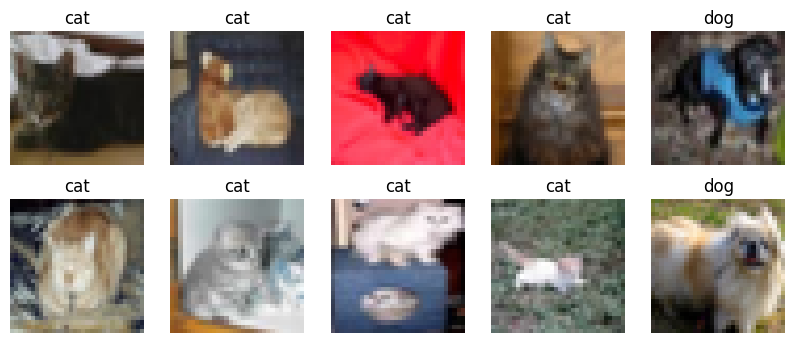

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical



# 1. CIFAR-10 데이터 로드
(x_train, y_train), (x_test, y_test) = cifar10.load_data()


# CIFAR-10 class index  클래스명과 인덱스
# airplane: 0
# automobile: 1
# bird: 2
# cat: 3
# deer: 4
# dog: 5
# frog: 6
# horse: 7
# ship: 8
# truck: 9

CAT_LABEL = 3
DOG_LABEL = 5

# 2. Cat / Dog 데이터만 선택

train_mask = np.where((y_train[:, 0] == CAT_LABEL) | (y_train[:, 0] == DOG_LABEL))[0]
test_mask = np.where((y_test[:, 0] == CAT_LABEL) | (y_test[:, 0] == DOG_LABEL))[0]

#(y_train[:,0]==3)  고양이인 위치 찾기
#np.where  조건을 만족하는 인덱스 반환

x_train_cd = x_train[train_mask]
y_train_cd = y_train[train_mask]

x_test_cd = x_test[test_mask]
y_test_cd = y_test[test_mask]


# 3. 라벨 변환  (이진분류 하기 위함)
# cat -> 0
# dog -> 1

y_train_cd = np.where(y_train_cd[:, 0] == CAT_LABEL, 0, 1)  # [:,0]  = 첫번째 열만 꺼냄
y_test_cd = np.where(y_test_cd[:, 0] == CAT_LABEL, 0, 1)


# 4. 정규화

x_train_cd = x_train_cd.astype("float32") / 255.0
x_test_cd = x_test_cd.astype("float32") / 255.0

print("Train data:", x_train_cd.shape)
print("Train label:", y_train_cd.shape)
print("Test data:", x_test_cd.shape)
print("Test label:", y_test_cd.shape)

# 5. 데이터 확인

class_names = ["cat", "dog"]

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_cd[i])
    plt.title(class_names[y_train_cd[i]])
    plt.axis("off")

plt.show()

##CNN 모델 학습 코드
- 학습 설정
- 학습 진행
- 테스트 정확도 평가
- 예측 결과 출력

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

# =========================
# 6. CNN 모델 생성
# =========================

model = Sequential()

# 첫 번째 합성곱 층
model.add(Conv2D(
    32,
    (3, 3),
    activation='relu',
    padding='same',
    input_shape=(32, 32, 3)
))

# 최대 풀링
model.add(MaxPooling2D((2, 2)))

# 두 번째 합성곱 층
model.add(Conv2D(
    64,
    (3, 3),
    activation='relu',
    padding='same'
))

# 최대 풀링
model.add(MaxPooling2D((2, 2)))

# 1차원으로 펼치기
model.add(Flatten())

# Dense 층
model.add(Dense(128, activation='relu'))

# 과적합 방지
model.add(Dropout(0.5))

# 출력층
model.add(Dense(1, activation='sigmoid'))

# =========================
# 7. 모델 컴파일
# =========================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 모델 구조 출력
model.summary()

# =========================
# 8. 모델 학습
# =========================

history = model.fit(
    x_train_cd,
    y_train_cd,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

# =========================
# 9. 모델 평가
# =========================

test_loss, test_acc = model.evaluate(
    x_test_cd,
    y_test_cd
)

print("Test Accuracy:", test_acc)

# =========================
# 10. 예측 결과 확인
# =========================

predictions = model.predict(x_test_cd[:10])

plt.figure(figsize=(12, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_cd[i])

    pred_label = 1 if predictions[i] > 0.5 else 0

    plt.title(
        f"Pred: {class_names[pred_label]}\n"
        f"True: {class_names[y_test_cd[i]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()